##**A Named Entity Recognition (NER)**

NER identifies and classifies important pieces of information (called **“entities”**) in text into predefined categories such as:

*   People (e.g., names of individuals)
*   Organizations (e.g., companies, universities)
*   Locations (e.g., cities, countries)
*   Dates and times
*   Other specific categories (like money, percentages, etc.)

Example:

**Barack Obama was born in Hawaii and was president of the United States.**

Entity Labels:

| Word   | Label |
| ------ | ----- |
| Barack | B-PER |
| Obama  | I-PER |
| Hawaii | B-LOC |
| United | B-LOC |
| States | I-LOC |

The process typically consists of the following steps:

**Text Analysis**

The system processes the entire text to identify words or phrases that may represent meaningful entities.

**Sentence Boundary Detection**

It determines the beginning and end of sentences using punctuation and capitalization, helping preserve context and meaning.

**Tokenization and Part-of-Speech Tagging**

The text is divided into smaller units called tokens (words or phrases). Each token is then assigned a grammatical tag (e.g., noun, verb), which provides important clues for identifying entities.

**Entity Detection and Classification**

The system identifies tokens or groups of tokens that match patterns of known entities and classifies them into predefined categories such as Person, Organization, Location, Date, etc.

**Model Training and Refinement**

Machine learning models are trained using labeled datasets. These models improve over time by learning linguistic patterns and relationships between words.

**Adaptation to New Contexts**

A well-trained NER model can generalize to different domains, languages, and writing styles, enabling it to recognize unseen entities based on contextual understanding.


##**Methods of Named Entity Recognition**

There are different methods present in NER which are:

###**01. Lexicon Based Name Entitiy Recognition Method**

The lexicon-based method relies on a precompiled dictionary (lexicon) of known entity names. During NER processing, the system checks the text for words or phrases that match entries in this dictionary.

In [ ]:
# Install spaCy
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 62.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Load the NLP Model
import spacy

nlp = spacy.load("en_core_web_sm")

In [ ]:
# Enter Text
text = input("Enter a sentence: ")

Enter a sentence: Barack Obama was born in Hawaii and worked at the University of Chicago.


In [ ]:
# Detect Entities
doc = nlp(text)

for ent in doc.ents:
    print(ent.text, "->", ent.label_)

Barack Obama -> PERSON
Hawaii -> GPE
the University of Chicago -> ORG


In [ ]:
# Highlight Entities
from spacy import displacy

displacy.render(doc, style="ent", jupyter=True)

###**Rule Based Name Entity Recognition Method**

The rule-based method relies on a set of predefined rules to identify and extract entities from text. These rules are typically derived from **patterns** in the text and the **context** in which words appear.

**Pattern-Based Rules:** Focus on the structure and form of words, including prefixes, suffixes, capitalization, and morphological patterns. For example, recognizing that words ending in “-ville” might indicate a location.

**Context-Based Rules:** Consider the surrounding words or phrases to determine the meaning of a potential entity. For instance, the word “Apple” followed by “Inc.” is likely an organization rather than a fruit.

In [ ]:
# Import libraries
import re
from IPython.display import display, HTML

In [ ]:
# Define rule based patterns
patterns = {
    "DATE": r"\b\d{4}\b",  # years like 2020
    "MONEY": r"\$\d+",     # $100
}

# context based rules
context_rules = {
    "ORG": ["Inc", "Ltd", "University", "Company", "Corp"],
    "LOC": ["city", "country", "state", "in"],
    "PER": ["Mr", "Mrs", "Dr", "President"]
}

In [ ]:
# Rule based NER function
def rule_based_ner(text):
    words = text.split()
    labels = ["O"] * len(words)

    # -------- Pattern-based detection --------
    for i, word in enumerate(words):
        for label, pattern in patterns.items():
            if re.match(pattern, word):
                labels[i] = label

    # -------- Context-based detection --------
    for i, word in enumerate(words):

        # PERSON rule (Mr John, Dr Smith)
        if i > 0 and words[i-1] in context_rules["PER"]:
            labels[i] = "PER"

        # ORGANIZATION rule (Google Inc, Apple Ltd)
        if i < len(words)-1 and words[i+1] in context_rules["ORG"]:
            labels[i] = "ORG"

        # LOCATION rule (in Berlin)
        if i > 0 and words[i-1] == "in":
            labels[i] = "LOC"

        # Capitalized words → possible entity
        if word.istitle() and labels[i] == "O":
            labels[i] = "MISC"

    return words, labels

In [ ]:
# Highlight outputs
def highlight_entities(words, labels):

    colors = {
        "PER": "lightgreen",
        "LOC": "lightblue",
        "ORG": "orange",
        "DATE": "pink",
        "MONEY": "yellow",
        "MISC": "lightgray"
    }

    output = ""

    for word, label in zip(words, labels):
        if label != "O":
            color = colors.get(label, "gray")
            output += f'<span style="background-color:{color}; padding:3px;">{word}</span> '
        else:
            output += word + " "

    display(HTML(output))
    # Corrected indentation and using 'colors' dictionary for the legend
    legend = "<b>Legend:</b> "
    for label, color in colors.items():
        legend += f'<span style="background-color:{color}; padding:3px; margin:2px;">{label}</span> '

    display(HTML(legend))

In [ ]:
text = input("Enter a sentence: ")

words, labels = rule_based_ner(text)

highlight_entities(words, labels)

Enter a sentence: Barack Obama was born in Hawaii and worked at the University of Chicago.


###**Machine Learning-Based Method: Multi-Class Classification**

Machine learning (ML) approaches to NER use algorithms to learn patterns from labeled datasets and automatically identify entities in new text.

**Multi-Class Classification:**

The model is trained on labeled examples, where each entity is assigned to a specific category (e.g., Person, Organization, Location). The algorithm learns to predict the correct category for each token or phrase in the text.

**Challenges:**

Requires large amounts of labeled data for training.
Needs a deep understanding of context and relationships between words, which can be difficult for simpler ML algorithms.
Performance depends heavily on feature selection, preprocessing, and quality of training data.

ML-based methods are widely used today because they can generalize better than lexicon- or rule-based methods and adapt to new or unseen entities.

In [ ]:
# Import libraries
import nltk # Natural Language Toolkit for text processing.
from sklearn.feature_extraction import DictVectorizer # Converts feature dictionaries to numeric vectors suitable for ML models.
from sklearn.linear_model import LogisticRegression # Classifiers for comparing performance.
from sklearn.model_selection import train_test_split # Splits data into training and testing sets.
from sklearn.metrics import classification_report, accuracy_score # Evaluate model performance.
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # Classifiers for comparing performance.
from sklearn.svm import LinearSVC # Classifiers for comparing performance.
from sklearn.naive_bayes import MultinomialNB # Classifiers for comparing performance.

**Proposed Workflow**

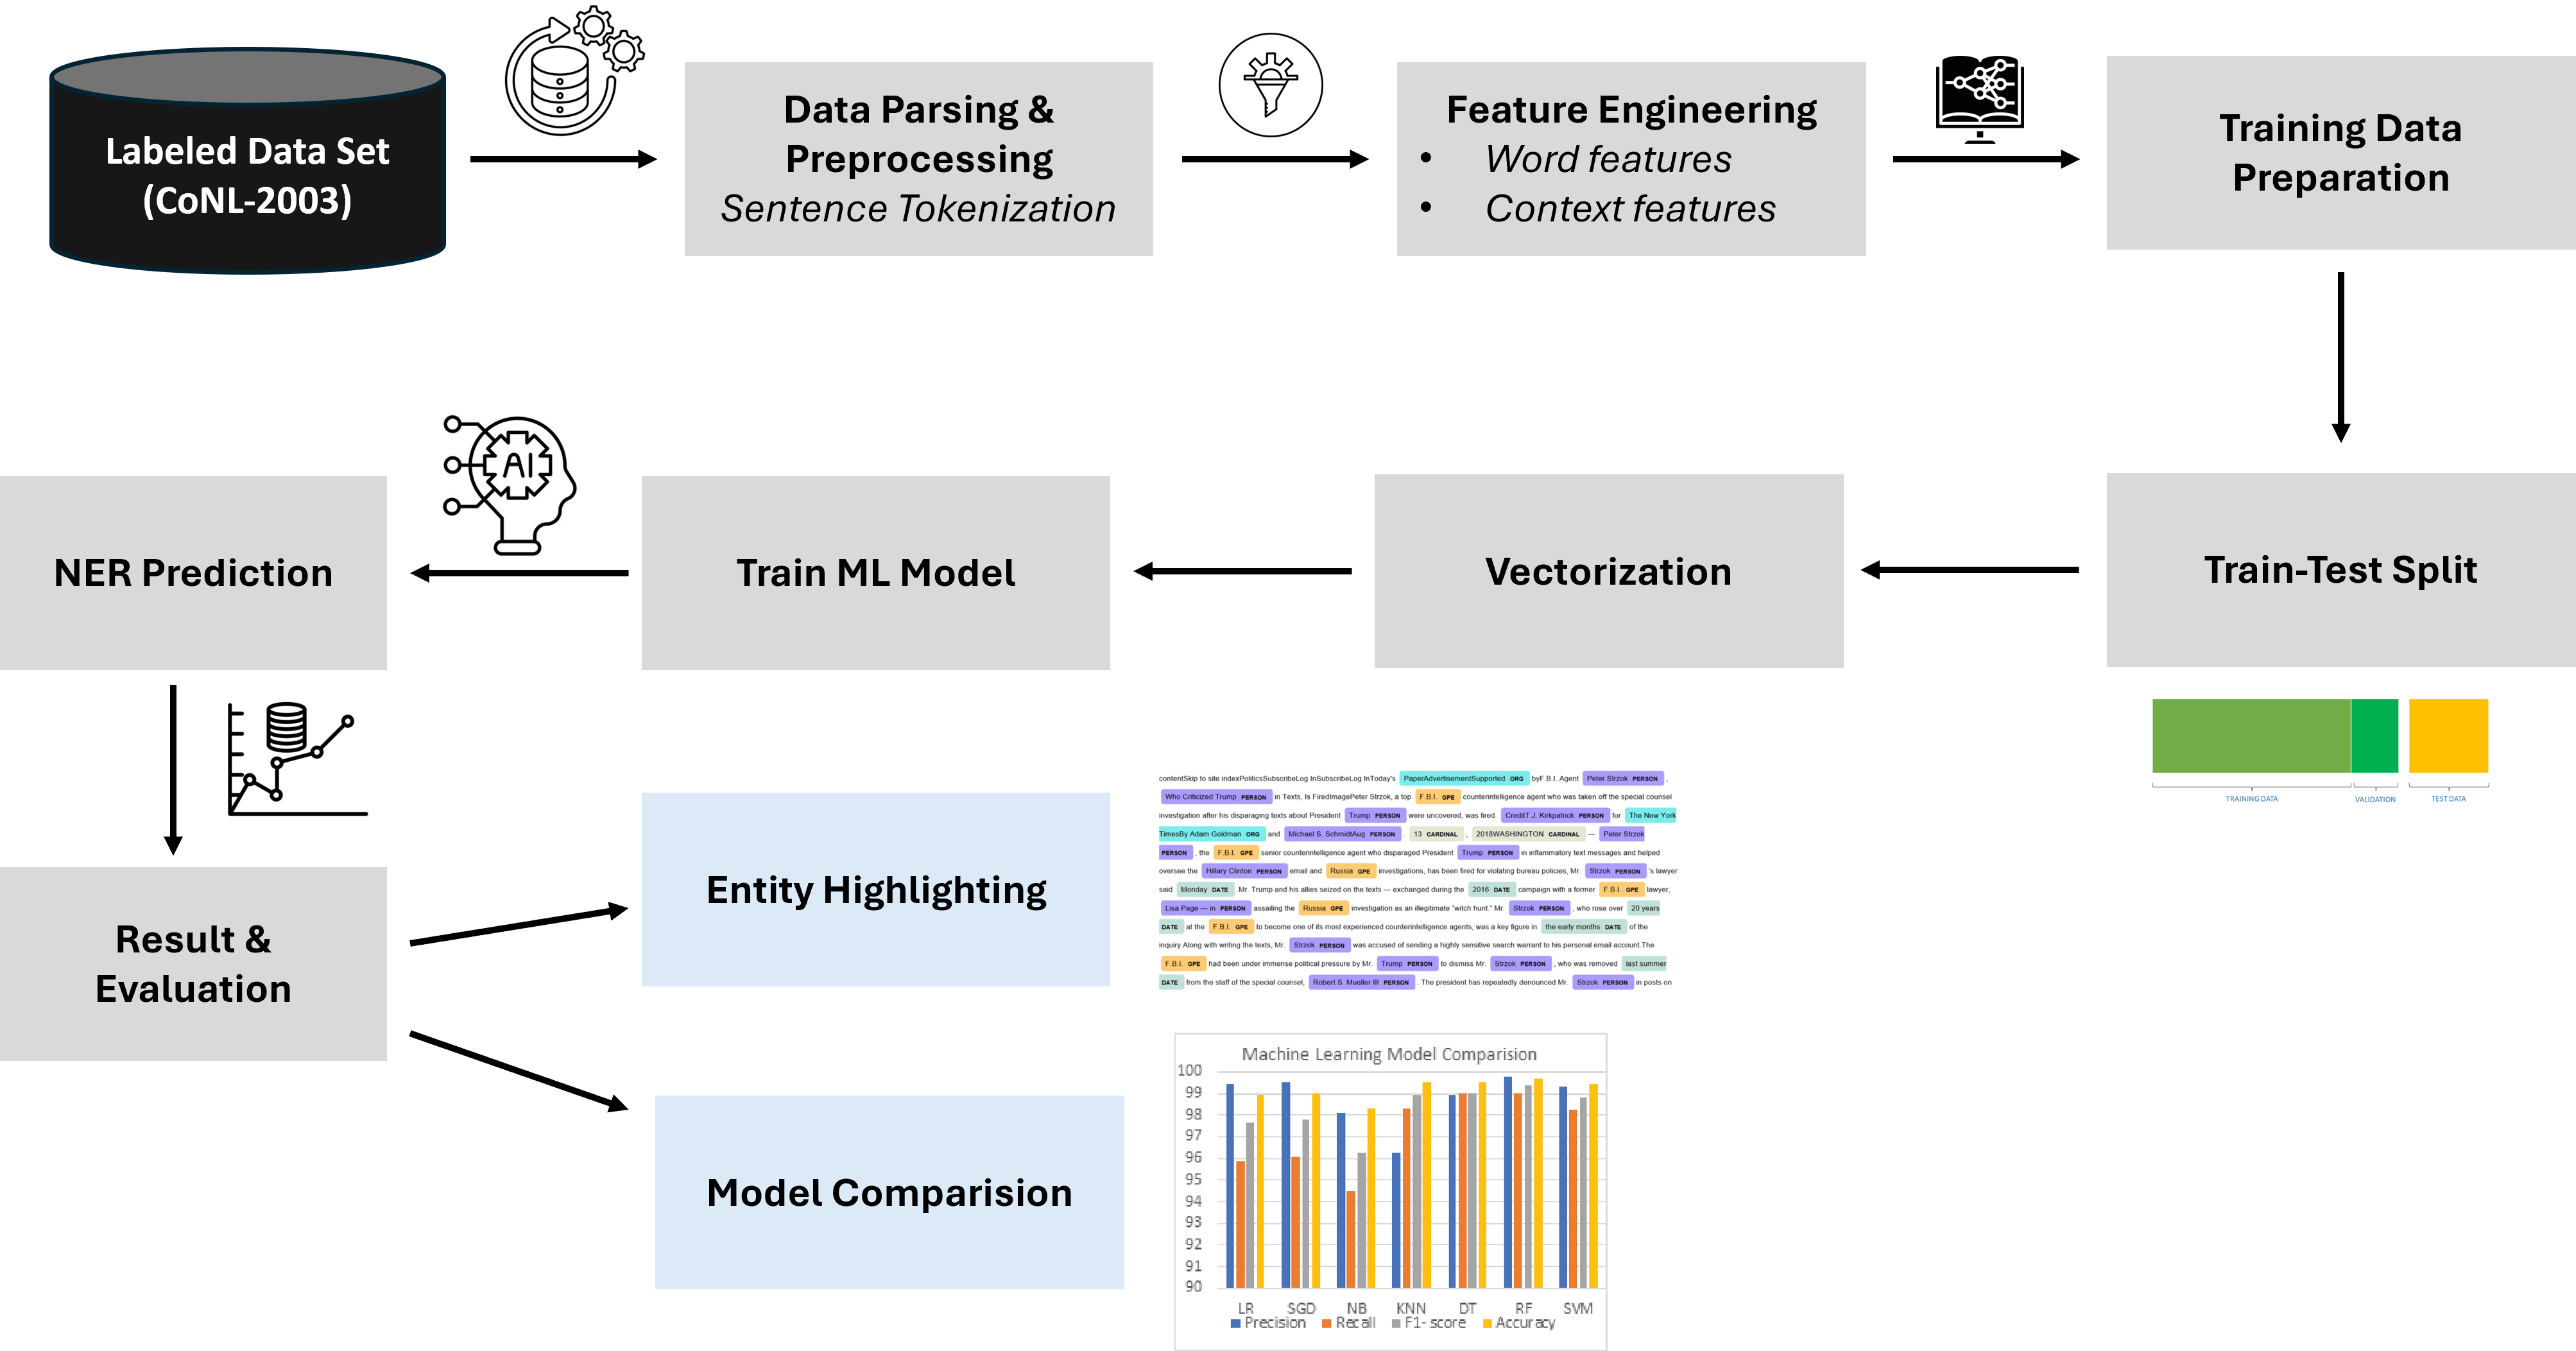

In [ ]:
# Export traning data (CoNLL-2003 dataset)
with open("/content/drive/MyDrive/Colab Notebooks/test.txt") as f:
    for i in range(10):
        print(f.readline())

# Parse Dataset into Sentences. Converts raw lines into a list of sentences.

sentences = []
sentence = []

with open("/content/drive/MyDrive/Colab Notebooks/test.txt", "r") as file:
    for line in file:

        line = line.strip()

        if line == "":
            if sentence:
                sentences.append(sentence)
                sentence = []
        else:
            parts = line.split()

            word = parts[0]
            label = parts[-1]

            sentence.append((word, label))

if sentence:
    sentences.append(sentence)

print(sentences[:2])

SOCCER NN B-NP O

- : O O

JAPAN NNP B-NP B-LOC

GET VB B-VP O

LUCKY NNP B-NP O

WIN NNP I-NP O

, , O O

CHINA NNP B-NP B-PER

IN IN B-PP O

SURPRISE DT B-NP O

[[('SOCCER', 'O'), ('-', 'O'), ('JAPAN', 'B-LOC'), ('GET', 'O'), ('LUCKY', 'O'), ('WIN', 'O'), (',', 'O'), ('CHINA', 'B-PER'), ('IN', 'O'), ('SURPRISE', 'O'), ('DEFEAT', 'O'), ('.', 'O')], [('Nadim', 'B-PER'), ('Ladki', 'I-PER')]]


In [ ]:
# Extract Labels
labels = set()
for sentence in sentences:
    for _, label in sentence:
        labels.add(label)

print(labels)

{'B-MISC', 'B-LOC', 'I-ORG', 'I-LOC', 'I-PER', 'O', 'I-MISC', 'B-ORG', 'B-PER'}


In [ ]:
# Feature Enginnering
def word_features(sentence, i):

    word = sentence[i][0]

    features = {
        "word.lower()": word.lower(),
        "word.isupper()": word.isupper(),
        "word.istitle()": word.istitle(),
        "word.isdigit()": word.isdigit(),
        "suffix-3": word[-3:],
        "suffix-2": word[-2:],
    }

    # previous word
    if i > 0:
        prev_word = sentence[i-1][0]
        features["prev_word"] = prev_word.lower()
    else:
        features["BOS"] = True

    # next word
    if i < len(sentence)-1:
        next_word = sentence[i+1][0]
        features["next_word"] = next_word.lower()
    else:
        features["EOS"] = True

    return features

For each word, create a dictionary of features:

**Word-level features**: lowercase, title case, uppercase, digits.

**Suffix features**: last 2-3 letters (helps detect patterns like -ing, -ion, -ly, etc.).

**Context features**: previous and next word.

**BOS/EOS**: Marks beginning or end of sentence.

These features allow the model to learn patterns for entity classification.

In [ ]:
# Prepare traning data
X = [] # feature dictionaries for every word.
y = [] # corresponding labels.

# each word has a feature vector and a target label.

for sentence in sentences:
    for i in range(len(sentence)):
        X.append(word_features(sentence, i))
        y.append(sentence[i][1])

In [ ]:
# Train test split
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Vectorize features
# Converts feature dictionaries into numeric vectors that ML models can process.
vec = DictVectorizer()

X_vector = vec.fit_transform(X)

X_train_vector = vec.fit_transform(X_train)
X_test_vector = vec.transform(X_test)

In [ ]:
# Train model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train_vector, y_train)

LogisticRegression(max_iter=200)

In [ ]:
# User input + prediction

# User enters a sentence, Extract features for each word, Predict entity labels using the trained model.

text = input("Enter a sentence: ")

words = text.split()

test_features = []

sentence_format = [(w,"") for w in words]

for i in range(len(words)):
    test_features.append(word_features(sentence_format,i))

X_test = vec.transform(test_features)

predictions = model.predict(X_test)

for w,p in zip(words,predictions):
    if p != "O":
        print(w,"->",p)

Enter a sentence: Barack Obama was born in Hawaii and worked at the University of Chicago.
Barack -> B-PER
Obama -> I-PER
Hawaii -> B-LOC
University -> B-ORG
Chicago. -> B-LOC


In [ ]:
# Entity highlight
from IPython.display import display, HTML

# Define colors for entity types
entity_colors = {
    "B-PER": "lightgreen",
    "I-PER": "green",
    "B-LOC": "lightblue",
    "I-LOC": "blue",
    "B-ORG": "orange",
    "I-ORG": "darkorange",
    "B-MISC": "pink",
    "I-MISC": "red"
}

highlighted_text = ""

for word, label in zip(words, predictions):
    if label != "O":
        color = entity_colors.get(label, "yellow")  # default if missing
        highlighted_text += f'<span style="background-color:{color};">{word}</span> '
    else:
        highlighted_text += word + " "

display(HTML(highlighted_text))

legend = "<b>Legend:</b> "
for label, color in entity_colors.items():
    legend += f'<span style="background-color:{color}; padding:3px; margin:2px;">{label}</span> '

display(HTML(legend))

In [ ]:
# Evaluation
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_vector)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9593914068359585

Detailed Report:

              precision    recall  f1-score   support

       B-LOC       0.84      0.84      0.84       295
      B-MISC       0.91      0.71      0.80       136
       B-ORG       0.84      0.80      0.82       353
       B-PER       0.81      0.86      0.83       327
       I-LOC       0.88      0.60      0.71        60
      I-MISC       0.93      0.49      0.64        53
       I-ORG       0.82      0.68      0.74       167
       I-PER       0.83      0.85      0.84       229
           O       0.98      1.00      0.99      7713

    accuracy                           0.96      9333
   macro avg       0.87      0.76      0.80      9333
weighted avg       0.96      0.96      0.96      9333



In [ ]:
# Compare Different Models

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# 1. Logistic Regression
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train_vector, y_train)
y_pred_lr = lr_model.predict(X_test_vector)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

# 2. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_vector, y_train)
y_pred_rf = rf_model.predict(X_test_vector)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# 3. Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_vector, y_train)
y_pred_gb = gb_model.predict(X_test_vector)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

# 4. Linear SVM
svm_model = LinearSVC(max_iter=5000)
svm_model.fit(X_train_vector, y_train)
y_pred_svm = svm_model.predict(X_test_vector)
print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

# 5. Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_vector, y_train)
y_pred_nb = nb_model.predict(X_test_vector)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Logistic Regression Accuracy: 0.9593914068359585
Random Forest Accuracy: 0.9508196721311475
Gradient Boosting Accuracy: 0.9223186542376514
Linear SVM Accuracy: 0.9675345548055287
Naive Bayes Accuracy: 0.9260687881710061


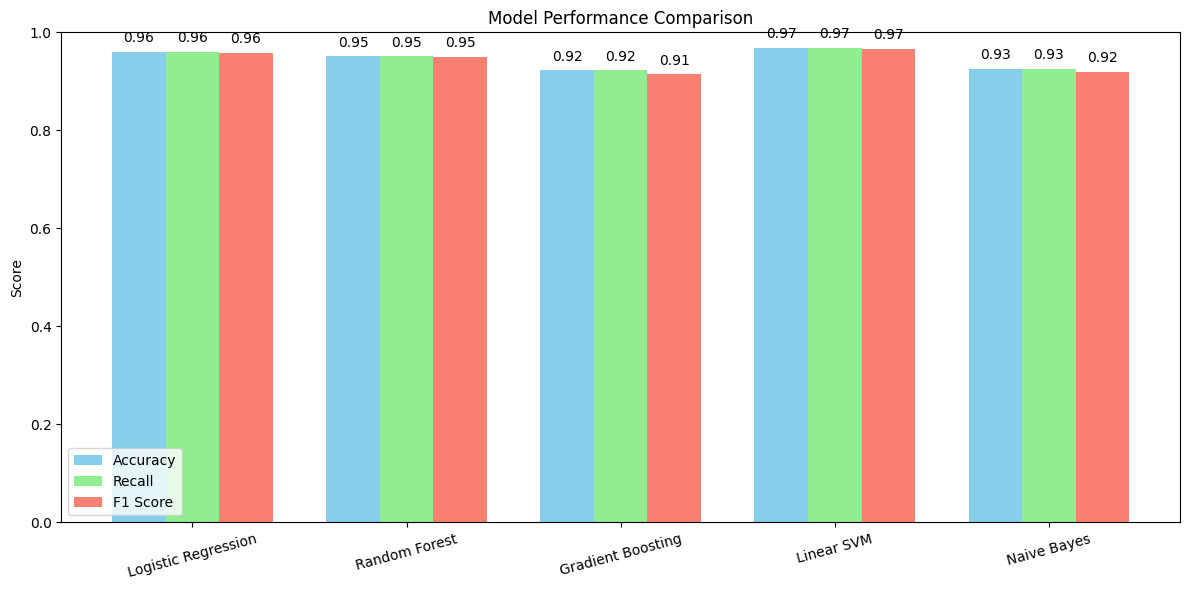

In [ ]:
# Comparison with bar graph
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, f1_score, accuracy_score
import numpy as np

models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'Linear SVM', 'Naive Bayes']
predictions = [y_pred_lr, y_pred_rf, y_pred_gb, y_pred_svm, y_pred_nb]

accuracies = [accuracy_score(y_test, pred) for pred in predictions]
recalls = [recall_score(y_test, pred, average='weighted') for pred in predictions]
f1_scores = [f1_score(y_test, pred, average='weighted') for pred in predictions]

x = np.arange(len(models))  # label locations
width = 0.25  # width of bars

plt.figure(figsize=(12, 6))
plt.bar(x - width, accuracies, width, label='Accuracy', color='skyblue')
plt.bar(x, recalls, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1_scores, width, label='F1 Score', color='salmon')
plt.xticks(x, models, rotation=15)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()

for i in range(len(models)):
    plt.text(i - width, accuracies[i] + 0.02, f'{accuracies[i]:.2f}', ha='center', fontsize=10)
    plt.text(i, recalls[i] + 0.02, f'{recalls[i]:.2f}', ha='center', fontsize=10)
    plt.text(i + width, f1_scores[i] + 0.02, f'{f1_scores[i]:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()